In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import catboost as cb
import src.features as features # pyright: ignore[reportMissingImports]
import src.plots as plots # pyright: ignore[reportMissingImports]

from config import PROCESSED_DATA # pyright: ignore[reportMissingImports]
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
modeling_df = pd.read_parquet(PROCESSED_DATA / 'modeling_df.parquet')

In [3]:
modeling_df.head()

,StockCode,InvoiceDate,Quantity,Revenue,lag_1w_qty,lag_2w_qty,lag_4w_qty,lag_8w_qty,lag_12w_qty,rolling_mean_4w_qty,rolling_mean_12w_qty,rolling_std_4w_qty,trend_ratio,rolling_cv_qty,sin_week,cos_week,is_q4,is_december,days_to_christmas
0,15036,2010-12-06,79,62.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.354605,0.935016,1,1,19
1,15036,2010-12-13,21,20.52,79.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.239316,0.970942,1,1,12
2,15036,2010-12-20,37,34.64,21.0,79.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.120537,0.992709,1,1,5
3,15036,2010-12-27,24,18.00,37.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1,1,0
4,15036,2011-01-10,37,41.00,24.0,37.0,79.0,NaN,NaN,40.25,NaN,26.750389,NaN,0.664606,0.239316,0.970942,0,0,90


In [4]:
# Dropping NaN values from the modeling DataFrame to ensure clean data for modeling
modeling_df = modeling_df.dropna()

In [5]:
# Converting 'StockCode' to a categorical data type to optimize memory usage and modeling performance
modeling_df["StockCode"] = modeling_df["StockCode"].astype("category")

In [6]:
# Chronological Train-Test Split: Using the last 8 weeks of data as the test set to evaluate model performance on the most recent sales patterns
unique_weeks = sorted(modeling_df["InvoiceDate"].unique())
train_weeks = unique_weeks[:-8]
test_weeks = unique_weeks[-8:]

train_data = modeling_df[modeling_df["InvoiceDate"].isin(train_weeks)]
test_data = modeling_df[modeling_df["InvoiceDate"].isin(test_weeks)]

In [7]:
# Defining the feature columns for modeling, including lag features, rolling statistics, trend indicators, and seasonal components
qty_features_col = [
    "StockCode",
    "lag_1w_qty", "lag_2w_qty", "lag_4w_qty", "lag_8w_qty", "lag_12w_qty",
    "rolling_mean_4w_qty", "rolling_mean_12w_qty", 
    "trend_ratio", "rolling_cv_qty",
    "sin_week", "cos_week", 
    "is_q4", "is_december", "days_to_christmas"
]

X_train = train_data[qty_features_col]
y_train = train_data["Quantity"]

X_test = test_data[qty_features_col]
y_test = test_data["Quantity"]

In [8]:
print(f"Training set shape: {X_train.shape} | Test set shape: {X_test.shape}")

Training set shape: (7656, 15) | Test set shape: (1856, 15)


#### Baseline

In [9]:
# Baseline Naive Forecast: Using the quantity from the same week in the previous year as a simple benchmark for model performance
test_data.loc[:, "naive_pred"] = test_data["lag_1w_qty"]

naive_wape = features.calculate_wape(test_data["Quantity"], test_data["naive_pred"])

/var/folders/rr/w51j34bd5tvdvk03fshtsc_w0000gn/T/ipykernel_8699/2152947471.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data.loc[:, "naive_pred"] = test_data["lag_1w_qty"]


#### LightGBM

In [10]:
lgb_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=10)
    ]
)

Training until validation scores don't improve for 100 rounds
[10]	valid_0's l2: 71191.9
[20]	valid_0's l2: 61592.1
[30]	valid_0's l2: 56538.1
[40]	valid_0's l2: 54541.3
[50]	valid_0's l2: 52915.8
[60]	valid_0's l2: 52428.9
[70]	valid_0's l2: 52311.3
[80]	valid_0's l2: 52225.3
[90]	valid_0's l2: 52495.5
[100]	valid_0's l2: 52541
[110]	valid_0's l2: 52468.2
[120]	valid_0's l2: 52896.2
[130]	valid_0's l2: 53042.6
[140]	valid_0's l2: 53300.4
[150]	valid_0's l2: 52995.5
[160]	valid_0's l2: 52754.9
[170]	valid_0's l2: 52844
Early stopping, best iteration is:
[77]	valid_0's l2: 52117.6


LGBMRegressor(learning_rate=0.05, max_depth=6, n_estimators=500, n_jobs=-1,
              random_state=42, verbose=-1)

In [11]:
# Evaluating model performance on the test set using MAE, RMSE, and R² metrics to assess prediction accuracy and goodness of fit
lgb_test_data_eval = test_data.copy()
lgb_test_data_eval["predicted_qty"] = lgb_model.predict(X_test)

lgb_mae = mean_absolute_error(lgb_test_data_eval["Quantity"], lgb_test_data_eval["predicted_qty"])
lgb_rmse = np.sqrt(mean_squared_error(lgb_test_data_eval["Quantity"], lgb_test_data_eval["predicted_qty"]))
lgb_r2 = r2_score(lgb_test_data_eval["Quantity"], lgb_test_data_eval["predicted_qty"])

# Calculating WAPE for the LightGBM model to compare against the Naive baseline and quantify the improvement in forecasting accuracy
lgb_wape = features.calculate_wape(lgb_test_data_eval["Quantity"], lgb_test_data_eval["predicted_qty"])

# Calculate percentage improvement of LightGBM over Naive baseline
lgb_improvement = ((naive_wape - lgb_wape)/ naive_wape) * 100

In [12]:
print("LightGBM Model Performance")
print(f"\nMean Absolute Error (MAE): {lgb_mae:.2f} items")
print(f"Root Mean Squared Error (RMSE): {lgb_rmse:.2f} items")
print(f"R-squared (R2 Score): {lgb_r2:.4f}")
print(f"\nNaive WAPE: {naive_wape:.2f}%")
print(f"LightGBM WAPE: {lgb_wape:.2f}%")
print(f"Improvement: {lgb_improvement:.2f}%")

LightGBM Model Performance

Mean Absolute Error (MAE): 95.47 items
Root Mean Squared Error (RMSE): 228.29 items
R-squared (R2 Score): 0.4461

Naive WAPE: 64.63%
LightGBM WAPE: 58.04%
Improvement: 10.20%


#### CatBoost

In [13]:
catboost_model = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="MAE",
    verbose=100,
    allow_writing_files=False
)

catboost_model.fit(
    X_train,
    y_train,
    cat_features=["StockCode"]
)

0:	learn: 106.4886745	total: 57.1ms	remaining: 28.5s
100:	learn: 69.2928355	total: 216ms	remaining: 852ms
200:	learn: 65.6293375	total: 374ms	remaining: 557ms
300:	learn: 61.9014383	total: 534ms	remaining: 353ms
400:	learn: 59.2507579	total: 697ms	remaining: 172ms
499:	learn: 57.1073624	total: 857ms	remaining: 0us


In [14]:
# Evaluating model performance on the test set using MAE, RMSE, and R² metrics to assess prediction accuracy and goodness of fit
cat_test_data_eval = test_data.copy()
cat_test_data_eval["predicted_qty"] = catboost_model.predict(X_test)

cat_mae = mean_absolute_error(cat_test_data_eval["Quantity"], cat_test_data_eval["predicted_qty"])
cat_rmse = np.sqrt(mean_squared_error(cat_test_data_eval["Quantity"], cat_test_data_eval["predicted_qty"]))
cat_r2 = r2_score(cat_test_data_eval["Quantity"], cat_test_data_eval["predicted_qty"])

# Calculating WAPE for the CatBoost model to compare against the Naive baseline and quantify the improvement in forecasting accuracy
cat_wape = features.calculate_wape(cat_test_data_eval["Quantity"], cat_test_data_eval["predicted_qty"])

# Calculate percentage improvement of CatBoost over Naive baseline
cat_improvement = ((naive_wape - cat_wape)/ naive_wape) * 100

In [15]:
print("CatBoost Model Performance")
print(f"\nMean Absolute Error (MAE): {cat_mae:.2f} items")
print(f"Root Mean Squared Error (RMSE): {cat_rmse:.2f} items")
print(f"R-squared (R2 Score): {cat_r2:.4f}")
print(f"\nNaive WAPE: {naive_wape:.2f}%")
print(f"CatBoost WAPE: {cat_wape:.2f}%")
print(f"Improvement: {cat_improvement:.2f}%")

CatBoost Model Performance

Mean Absolute Error (MAE): 87.66 items
Root Mean Squared Error (RMSE): 237.32 items
R-squared (R2 Score): 0.4015

Naive WAPE: 64.63%
CatBoost WAPE: 53.29%
Improvement: 17.54%


#### XGBoost

In [16]:
xgboost_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,
    early_stopping_rounds=100,
    verbosity=0
)

xgboost_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)]
)

[0]	validation_0-rmse:302.77024
[1]	validation_0-rmse:297.53230
[2]	validation_0-rmse:292.98325
[3]	validation_0-rmse:288.61611
[4]	validation_0-rmse:284.80490
[5]	validation_0-rmse:280.97974
[6]	validation_0-rmse:277.51948
[7]	validation_0-rmse:274.39359
[8]	validation_0-rmse:270.80968
[9]	validation_0-rmse:267.75431
[10]	validation_0-rmse:265.15010
[11]	validation_0-rmse:263.19556
[12]	validation_0-rmse:261.24882
[13]	validation_0-rmse:258.70842
[14]	validation_0-rmse:256.08191
[15]	validation_0-rmse:254.59071
[16]	validation_0-rmse:252.52319
[17]	validation_0-rmse:251.16601
[18]	validation_0-rmse:249.64909
[19]	validation_0-rmse:248.62639
[20]	validation_0-rmse:247.75963
[21]	validation_0-rmse:246.85745
[22]	validation_0-rmse:246.38591
[23]	validation_0-rmse:244.89590
[24]	validation_0-rmse:244.32115
[25]	validation_0-rmse:243.98175
[26]	validation_0-rmse:243.32431
[27]	validation_0-rmse:242.68243
[28]	validation_0-rmse:241.72008
[29]	validation_0-rmse:240.79494
[30]	validation_0-rm

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=100,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [17]:
# Evaluating model performance on the test set using MAE, RMSE, and R² metrics to assess prediction accuracy and goodness of fit
xgb_test_data_eval = test_data.copy()
xgb_test_data_eval["predicted_qty"] = xgboost_model.predict(X_test)

xgb_mae = mean_absolute_error(xgb_test_data_eval["Quantity"], xgb_test_data_eval["predicted_qty"])
xgb_rmse = np.sqrt(mean_squared_error(xgb_test_data_eval["Quantity"], xgb_test_data_eval["predicted_qty"]))
xgb_r2 = r2_score(xgb_test_data_eval["Quantity"], xgb_test_data_eval["predicted_qty"])

# Calculating WAPE for the XGBoost model to compare against the Naive baseline and quantify the improvement in forecasting accuracy
xgb_wape = features.calculate_wape(xgb_test_data_eval["Quantity"], xgb_test_data_eval["predicted_qty"])

# Calculate percentage improvement of XGBoost over Naive baseline
xgb_improvement = ((naive_wape - xgb_wape)/ naive_wape) * 100

In [18]:
print("XGBoost Model Performance")
print(f"\nMean Absolute Error (MAE): {xgb_mae:.2f} items")
print(f"Root Mean Squared Error (RMSE): {xgb_rmse:.2f} items")
print(f"R-squared (R2 Score): {xgb_r2:.4f}")
print(f"\nNaive WAPE: {naive_wape:.2f}%")
print(f"XGBoost WAPE: {xgb_wape:.2f}%")
print(f"Improvement: {xgb_improvement:.2f}%")

XGBoost Model Performance

Mean Absolute Error (MAE): 96.91 items
Root Mean Squared Error (RMSE): 236.37 items
R-squared (R2 Score): 0.4062

Naive WAPE: 64.63%
XGBoost WAPE: 58.92%
Improvement: 8.84%


#### Model Comparison

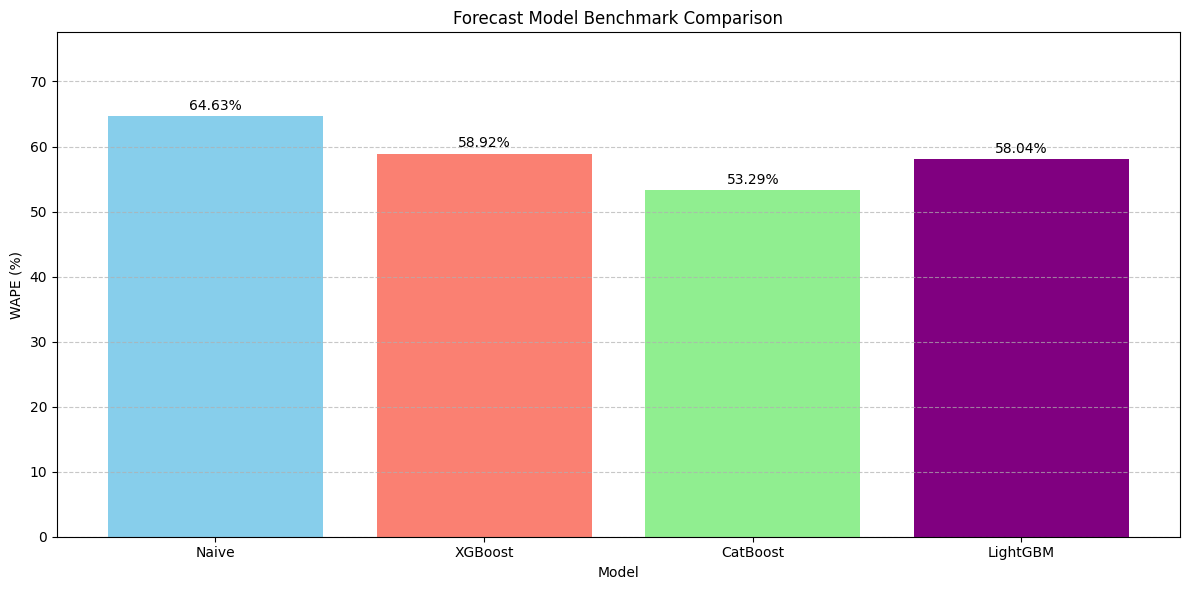

In [19]:
models = ["Naive", "XGBoost", "CatBoost", "LightGBM"]
wape_values = [naive_wape, xgb_wape, cat_wape, lgb_wape]

plots.plot_model_comparison(models, wape_values)

In [20]:
# Saving the evaluation results for the CatBoost model to a Parquet file for future analysis and reporting
cat_test_data_eval.to_parquet(PROCESSED_DATA / 'cat_test_data_eval.parquet')